In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")

# Lectura de archivos

In [37]:
ruta = './Data/'
clientes = pd.read_excel(f'{ruta}Clientes.xlsx')
Detalle_ventas = pd.read_excel(f'{ruta}Detalle_ventas.xlsx')
Productos = pd.read_excel(f'{ruta}Productos.xlsx')
Ventas = pd.read_excel(f'{ruta}Ventas.xlsx')

In [38]:
clientes.head(2)

,id_cliente,nombre_cliente,email,ciudad,fecha_alta
0,1,Mariana Lopez,mariana.lopez@mail.com,Carlos Paz,2023-01-01
1,2,Nicolas Rojas,nicolas.rojas@mail.com,Carlos Paz,2023-01-02


In [39]:
Detalle_ventas.head(5)

,id_venta,id_producto,nombre_producto,cantidad,precio_unitario,importe
0,1,90,Toallas Húmedas x50,1,2902,2902
1,2,82,Aceitunas Negras 200g,5,2394,11970
2,2,39,Helado Vainilla 1L,5,469,2345
3,2,70,Fernet 750ml,2,4061,8122
4,2,22,Medialunas de Manteca,1,2069,2069


In [40]:
Productos.head(2)

,id_producto,nombre_producto,categoria,precio_unitario
0,1,Coca Cola 1.5L,Alimentos,2347
1,3,Sprite 1.5L,Alimentos,4964


In [41]:
Ventas.head(5)

,id_venta,fecha,id_cliente,nombre_cliente,apellido_cliente,email,medio_pago
0,1,2024-06-19,62,Guadalupe,Romero,guadalupe.romero@mail.com,tarjeta
1,2,2024-03-17,49,Olivia,Gomez,olivia.gomez@mail.com,qr
2,3,2024-01-13,20,Tomas,Acosta,tomas.acosta@mail.com,tarjeta
3,4,2024-02-27,36,Martina,Molina,martina.molina@mail.com,transferencia
4,5,2024-06-11,56,Bruno,Diaz,bruno.diaz@mail.com,tarjeta


# Analisis

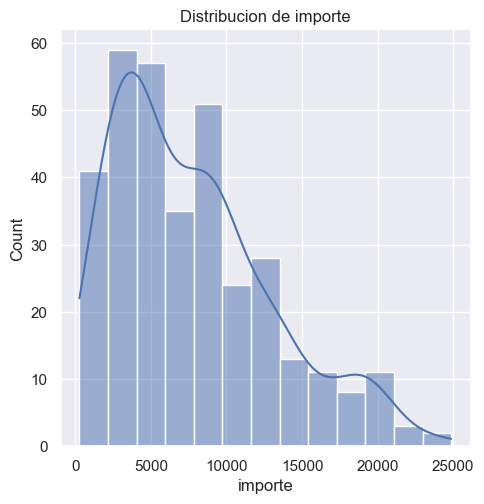

In [ ]:
sns.displot(Detalle_ventas['importe'], kde = True)
plt.title('Distribución de importe')
plt.show()

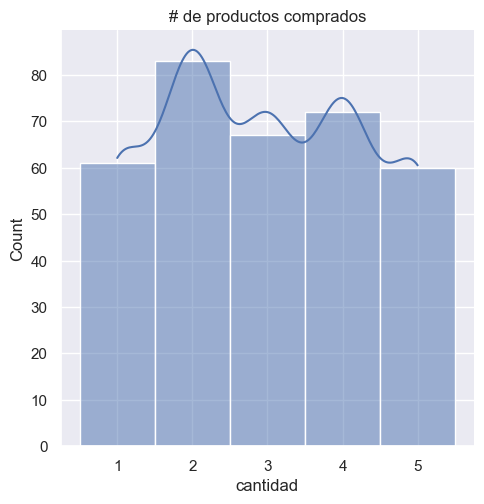

In [179]:
sns.displot(Detalle_ventas['cantidad'], kde = True, discrete = True)
plt.title('# de productos comprados')
plt.show()

In [ ]:
#Numero de veces que compra el cliente
Cantidad = Ventas[['id_cliente', 'nombre_cliente']].groupby(by = 'id_cliente').count()
Cantidad = Cantidad.rename(columns={'nombre_cliente':'Numero_compras'})
Cantidad.describe()

,Numero_compras
count,67.000000
mean,1.791045
std,0.946081
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,5.000000


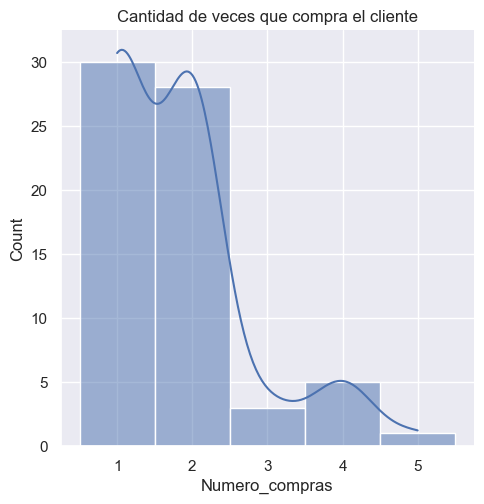

In [180]:
sns.displot(data = Cantidad['Numero_compras'], kde = True,discrete = True)
plt.title('Cantidad de veces que compra el cliente')
plt.show()

In [77]:
Ventas_categorias = (Detalle_ventas.merge(
    Productos, on='id_producto'
))
Ventas_categorias.describe()

,id_venta,id_producto,cantidad,precio_unitario_x,importe,precio_unitario_y
count,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000
mean,61.492711,49.139942,2.962099,2654.495627,7730.078717,2654.495627
std,34.835525,29.135461,1.366375,1308.694720,5265.543077,1308.694720
min,1.000000,1.000000,1.000000,272.000000,272.000000,272.000000
25%,31.000000,23.000000,2.000000,1618.500000,3489.000000,1618.500000
50%,61.000000,47.000000,3.000000,2512.000000,6702.000000,2512.000000
75%,93.000000,76.000000,4.000000,3876.000000,10231.500000,3876.000000
max,120.000000,100.000000,5.000000,4982.000000,24865.000000,4982.000000


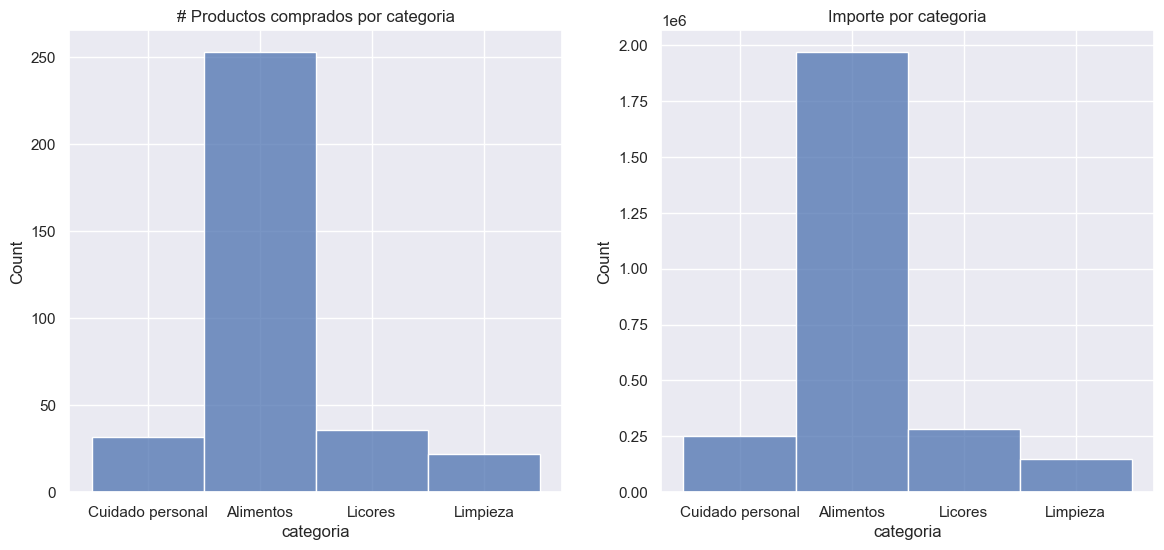

In [113]:
fig, ax = plt.subplots(1,2, figsize = (14,6))
orden = ['Alimentos', 'Licores', 'Cuidado personal', 'Limpieza']

sns.histplot(data = Ventas_categorias['categoria'], ax = ax[0])
ax[0].set_title('# Productos comprados por categoria')

sns.histplot(data=Ventas_categorias,x='categoria',weights='importe',ax = ax[1])
ax[1].set_title('Importe por categoria')
plt.show()

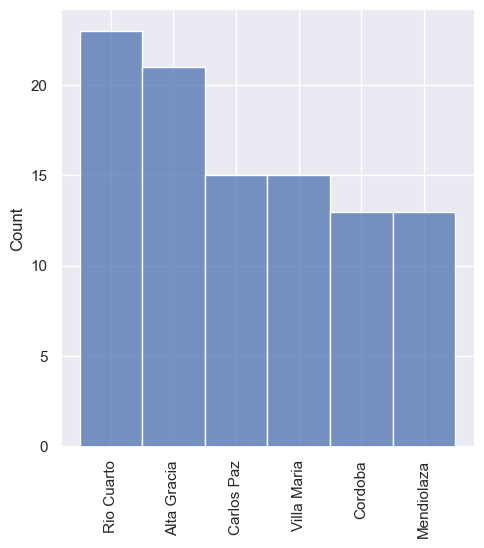

In [132]:
orden = list(
    clientes['ciudad']
    .value_counts()
    .sort_values(ascending=False)
    .index
)
sns.displot(data = pd.Categorical(clientes['ciudad'], categories=orden, ordered=True))
plt.xticks(rotation = 90)
plt.show()

## Descripcion de variables

In [50]:
Detalle_ventas.describe()

,id_venta,id_producto,cantidad,precio_unitario,importe
count,343.000000,343.000000,343.000000,343.000000,343.000000
mean,61.492711,49.139942,2.962099,2654.495627,7730.078717
std,34.835525,29.135461,1.366375,1308.694720,5265.543077
min,1.000000,1.000000,1.000000,272.000000,272.000000
25%,31.000000,23.000000,2.000000,1618.500000,3489.000000
50%,61.000000,47.000000,3.000000,2512.000000,6702.000000
75%,93.000000,76.000000,4.000000,3876.000000,10231.500000
max,120.000000,100.000000,5.000000,4982.000000,24865.000000


In [51]:
Ventas.describe()

,id_venta,fecha,id_cliente
count,120.000000,120,120.000000
mean,60.500000,2024-03-29 17:36:00,47.291667
min,1.000000,2024-01-02 00:00:00,1.000000
25%,30.750000,2024-02-11 06:00:00,24.500000
50%,60.500000,2024-03-25 00:00:00,48.500000
75%,90.250000,2024-05-19 06:00:00,67.500000
max,120.000000,2024-06-28 00:00:00,100.000000
std,34.785054,NaN,27.854181


## Correlacion

In [52]:
Tabla_correlacion = (Ventas.merge(Detalle_ventas, how = 'inner', on = 'id_venta')
                     .merge(Productos, how = 'inner', on = 'id_producto')
                     .merge(clientes, how = 'inner', on = 'id_cliente')
                     .merge(Cantidad, on = 'id_cliente'))
Tabla_correlacion = Tabla_correlacion[['medio_pago', 'cantidad', 'importe', 'precio_unitario_x', 'categoria', 'ciudad', 'Numero_compras']]
Tabla_correlacion

,medio_pago,cantidad,importe,precio_unitario_x,categoria,ciudad,Numero_compras
0,tarjeta,1,2902,2902,Cuidado personal,Carlos Paz,2
1,qr,5,11970,2394,Alimentos,Rio Cuarto,4
2,qr,5,2345,469,Alimentos,Rio Cuarto,4
3,qr,2,8122,4061,Licores,Rio Cuarto,4
4,qr,1,2069,2069,Alimentos,Rio Cuarto,4
...,...,...,...,...,...,...,...
338,efectivo,2,8122,4061,Licores,Cordoba,2
339,efectivo,3,6426,2142,Cuidado personal,Cordoba,2
340,efectivo,2,1454,727,Alimentos,Cordoba,2
341,qr,5,3725,745,Alimentos,Rio Cuarto,2


In [53]:
diccionario = dict(enumerate(Tabla_correlacion.medio_pago.unique()))
Tabla_correlacion['medio_pago'] = Tabla_correlacion['medio_pago'].replace({valor: clave for clave, valor in diccionario.items()})
diccionario = dict(enumerate(Tabla_correlacion.categoria.unique()))
Tabla_correlacion['categoria'] = Tabla_correlacion['categoria'].replace({valor: clave for clave, valor in diccionario.items()})
diccionario = dict(enumerate(Tabla_correlacion.ciudad.unique()))
Tabla_correlacion['ciudad'] = Tabla_correlacion['ciudad'].replace({valor: clave for clave, valor in diccionario.items()})

C:\Users\Andres\AppData\Local\Temp\ipykernel_6872\667642832.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Tabla_correlacion['medio_pago'] = Tabla_correlacion['medio_pago'].replace({valor: clave for clave, valor in diccionario.items()})
C:\Users\Andres\AppData\Local\Temp\ipykernel_6872\667642832.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Tabla_correlacion['categoria'] = Tabla_correlacion['categoria'].replace({valor: clave for clave, valor in diccionario.items()})
C:\Users\Andres\AppData\Local\Temp\ipykernel_6872\6676

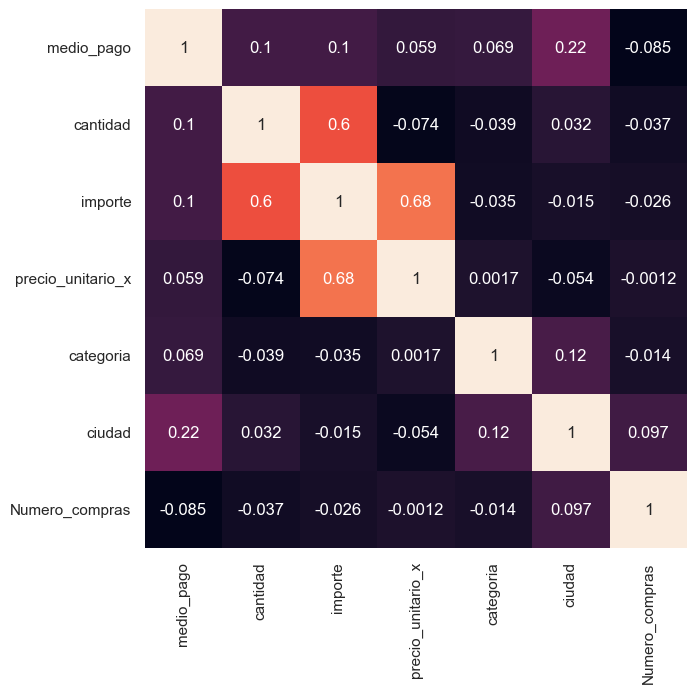

In [136]:
plt.figure(figsize=(7,7))
sns.heatmap(Tabla_correlacion.corr(), annot=True, cbar = False)
plt.show()

In [137]:
Ventas_historicas = (Ventas.merge(Detalle_ventas, how = 'inner', on = 'id_venta')
                     .merge(Productos, how = 'inner', on = 'id_producto'))
Ventas_historicas["fecha"] = pd.to_datetime(Ventas_historicas["fecha"])
Ventas_historicas.head()

,id_venta,fecha,id_cliente,nombre_cliente,apellido_cliente,email,medio_pago,id_producto,nombre_producto_x,cantidad,precio_unitario_x,importe,nombre_producto_y,categoria,precio_unitario_y
0,1,2024-06-19,62,Guadalupe,Romero,guadalupe.romero@mail.com,tarjeta,90,Toallas Húmedas x50,1,2902,2902,Toallas Húmedas x50,Cuidado personal,2902
1,2,2024-03-17,49,Olivia,Gomez,olivia.gomez@mail.com,qr,82,Aceitunas Negras 200g,5,2394,11970,Aceitunas Negras 200g,Alimentos,2394
2,2,2024-03-17,49,Olivia,Gomez,olivia.gomez@mail.com,qr,39,Helado Vainilla 1L,5,469,2345,Helado Vainilla 1L,Alimentos,469
3,2,2024-03-17,49,Olivia,Gomez,olivia.gomez@mail.com,qr,70,Fernet 750ml,2,4061,8122,Fernet 750ml,Licores,4061
4,2,2024-03-17,49,Olivia,Gomez,olivia.gomez@mail.com,qr,22,Medialunas de Manteca,1,2069,2069,Medialunas de Manteca,Alimentos,2069


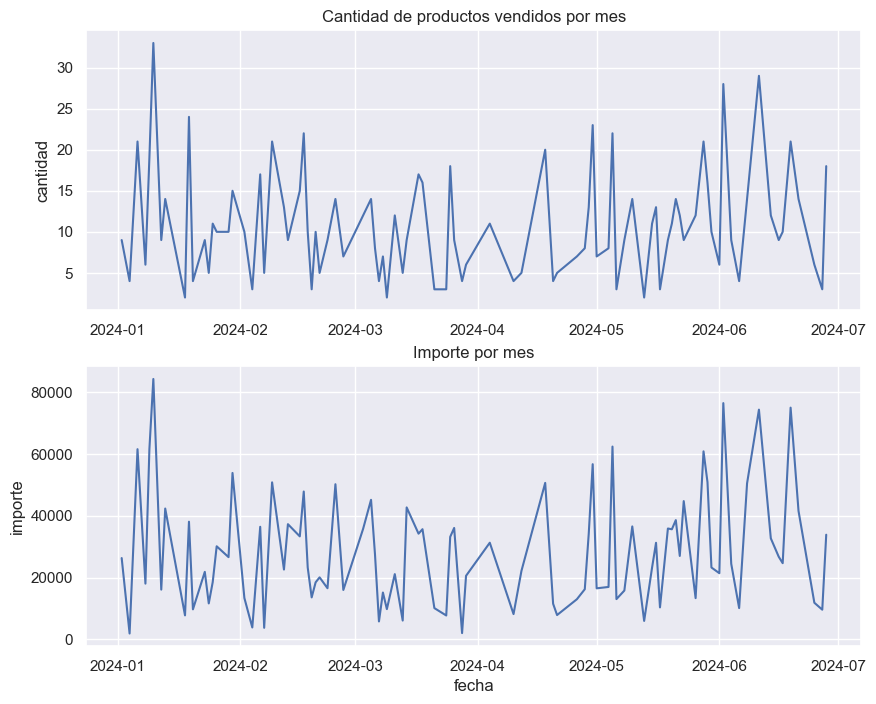

In [156]:
Ventas2 = Ventas_historicas[['fecha', 'cantidad', 'importe']].groupby(by = ['fecha']).sum()
fig,ax = plt.subplots(2,1,figsize=(10, 8))
sns.lineplot(x = 'fecha', y = 'cantidad', data = Ventas2, ax = ax[0])
ax[0].set_title('Cantidad de productos vendidos por mes')
ax[0].set_xlabel('')
sns.lineplot(x = 'fecha', y = 'importe', data = Ventas2, ax = ax[1])
ax[1].set_title('Importe por mes')
plt.show()

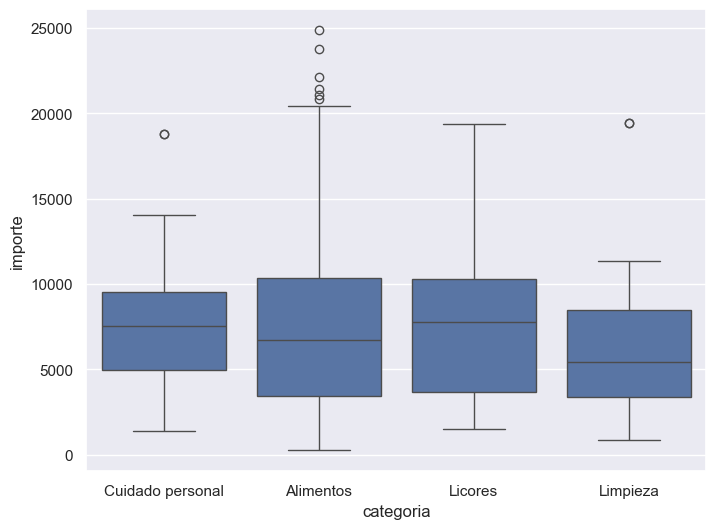

In [157]:
fig = plt.subplots(figsize=(8, 6))
sns.boxplot(x = Ventas_historicas['categoria'], y = Ventas_historicas['importe'])
plt.show()

In [175]:
ax[0].get_legend_handles_labels()

([<matplotlib.lines.Line2D at 0x1409d3d6d80>,
 ['Alimentos', 'Licores', 'Limpieza', 'Cuidado personal'])

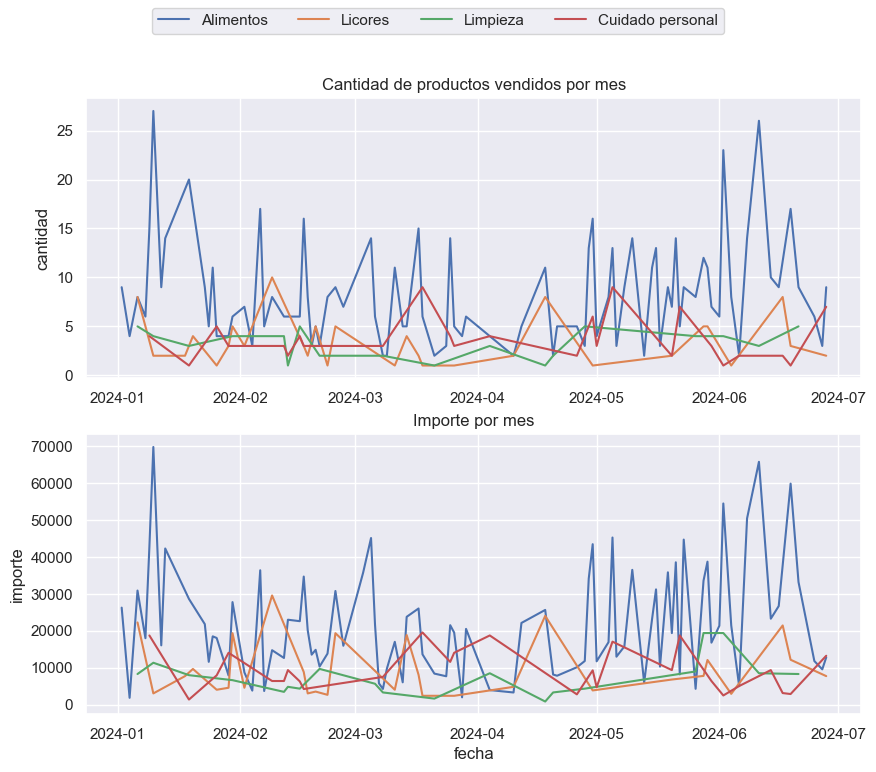

In [178]:
Ventas2 = Ventas_historicas[['fecha', 'importe', 'categoria', 'cantidad']].groupby(by = ['fecha', 'categoria']).sum()
fig,ax = plt.subplots(2,1,figsize=(10, 8))
sns.lineplot(x = 'fecha', y = 'cantidad', data = Ventas2, ax = ax[0], hue = 'categoria')
ax[0].set_title('Cantidad de productos vendidos por mes')
ax[0].set_xlabel('')
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend_.remove()
sns.lineplot(x = 'fecha', y = 'importe', data = Ventas2, ax = ax[1], hue = 'categoria', legend=False)
ax[1].set_title('Importe por mes')
fig.legend(
    handles, labels,
    loc='upper center',
    ncol=4,
)
plt.show()